In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import netCDF4 as nc

import sys
sys.path.append('/home/z5297792/UNSW-MRes/MRes/SEACOFS_dataset') 
from clim_functions import tilt_distance_Li, plot_tilt_method, bearing


In [2]:
df_ameda = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/AMEDA/df_ameda_renamed.pkl')
df_tilt = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/AMEDA/df_tilt_ameda.pkl')
df_ameda = df_ameda.merge(
    df_tilt[['Eddy', 'Day', 'TiltDis', 'TiltDir']],
    how='left',
    left_on=['Eddy', 'Day'],
    right_on=['Eddy', 'Day']
)
df_AE = df_ameda[df_ameda.Cyc=='AE'].copy()
df_CE = df_ameda[df_ameda.Cyc=='CE'].copy()
df_ameda


,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,split2,merge,merge2,shapes2,interaction,interaction2,area,deta,TiltDis,TiltDir
0,1,1462,AE,159.538447,-33.372496,256,186,895.838095,919.548973,0.000010,...,NaN,NaN,NaN,NaN,NaN,NaN,46653.514371,-0.000011,NaN,NaN
1,1,1463,AE,159.686966,-33.160751,257,192,903.002279,946.853133,0.000019,...,NaN,NaN,NaN,NaN,NaN,NaN,4313.383226,-0.000164,NaN,NaN
2,1,1464,AE,159.649836,-33.118402,256,192,898.424872,950.150915,0.000019,...,NaN,NaN,NaN,NaN,NaN,NaN,4336.799061,-0.000070,NaN,NaN
3,1,1465,AE,159.686966,-33.118402,257,193,901.765461,951.353349,0.000019,...,NaN,NaN,NaN,NaN,NaN,NaN,6480.379311,-0.000047,16.147158,80.585819
4,1,1466,AE,159.575577,-32.949006,254,196,886.770848,965.738198,0.000020,...,NaN,NaN,NaN,NaN,NaN,NaN,6101.676103,-0.000401,19.455358,63.680275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104565,3519,10643,CE,154.897235,-28.841152,125,252,327.112431,1244.142958,-0.000014,...,NaN,NaN,NaN,NaN,NaN,NaN,1147.953129,0.000186,8.196140,194.802223
104566,3519,10647,CE,154.860106,-29.052897,127,247,331.141370,1220.843200,-0.000011,...,NaN,NaN,NaN,NaN,NaN,NaN,8038.013328,0.000109,43.813072,358.254256
104567,3519,10648,CE,154.897235,-29.222293,130,244,340.502393,1204.416117,-0.000011,...,NaN,NaN,NaN,NaN,NaN,NaN,9866.414298,0.000095,NaN,NaN
104568,3519,10649,CE,154.377420,-28.417662,100,257,264.105244,1270.945276,-0.000010,...,NaN,NaN,NaN,NaN,NaN,NaN,5581.424065,0.000003,NaN,NaN


In [3]:
dic_vert = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/AMEDA/dic_vert_doppio_AMEDA.pkl')


In [4]:
df_ameda['day_idx'] = (
    df_ameda.groupby('Eddy')['Day']
    .transform(lambda x: x - x.iloc[0])
)
df_large_tilt = df_ameda[df_ameda.TiltDis > 250]
df_large_tilt


,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,merge,merge2,shapes2,interaction,interaction2,area,deta,TiltDis,TiltDir,day_idx
9910,326,2323,AE,156.196775,-27.613030,151,287,404.776051,1415.742073,0.000016,...,NaN,NaN,"Path(array([[157.01362781, -28.34454901],\n ...",2032.0,NaN,5560.463621,-0.000063,255.304760,325.138730,16
19712,647,3310,AE,154.488809,-32.398469,154,174,413.157910,859.564127,0.000013,...,NaN,NaN,NaN,4401.0,NaN,7331.768264,-0.000079,263.926561,11.968629,32


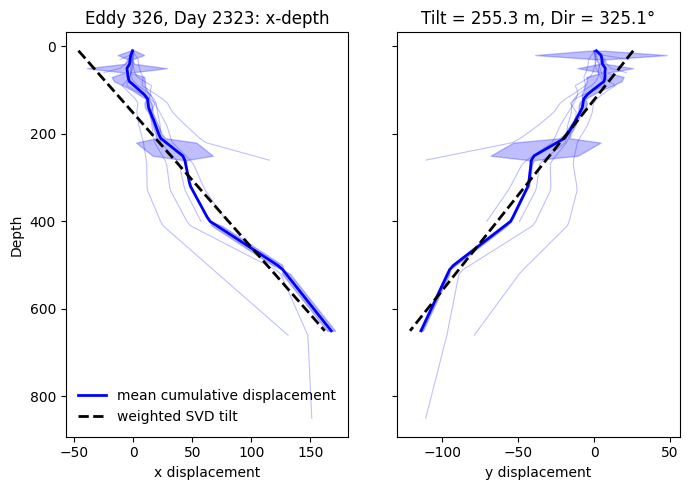

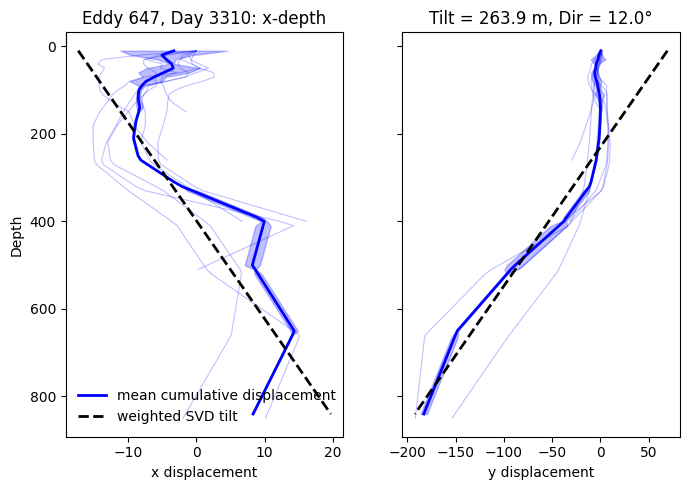

In [5]:
# ks = np.array([10, 50, 70, 100, 10, 130, 140, 150, 180, 200])
# ks += 7

for k in range(len(df_large_tilt)):

    data = df_large_tilt.iloc[k]
    eddy, ref_day = data.Eddy, data.day_idx
    
    plot_tilt_method(
        dic_all=dic_vert,
        eddy=eddy,
        ref_day_idx=ref_day,
        ax_x=None,
        ax_y=None,
        num=6,
        depth_int=10,
        max_depth=1000,
        min_depth_range=200,
        color='b',
        show=True
    )



In [6]:
max_spreads = []
for row in df_ameda.itertuples(index=False):
    try:
        df = dic_vert[f'Eddy{row.Eddy}'][f'Day{row.Day}']

        max_spread, _, _ = tilt_distance_Li(
            df['xc'].values,
            df['yc'].values,
            np.abs(df['Depth'].values),
            zmax=1000
        )
    except Exception:
        max_spread = np.nan
    max_spreads.append(max_spread)

df_ameda['max_spread'] = max_spreads


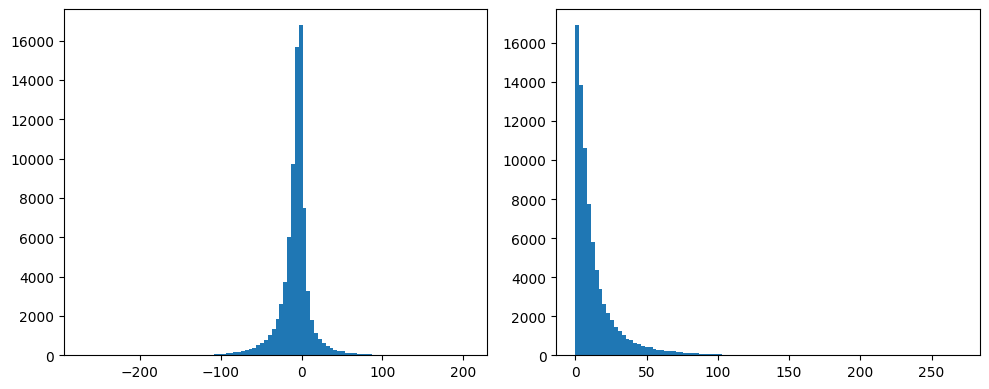

In [21]:
df_ameda['tdiff'] = df_ameda.TiltDis - df_ameda.max_spread
df_ameda['tdiff_abs'] = (df_ameda.TiltDis - df_ameda.max_spread).abs()
fig, axs = plt.subplots(1,2, figsize=(10, 4))
axs[0].hist(df_ameda['tdiff'], bins=100)
axs[1].hist(df_ameda['tdiff_abs'], bins=100)
plt.tight_layout()


In [23]:
df_over_tilt = df_ameda[df_ameda.tdiff > 150] # i.e. the tilt is significantly larger than the spread of centers
df_over_tilt


,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,interaction,interaction2,area,deta,TiltDis,TiltDir,day_idx,max_spread,tdiff,tdiff_abs
9798,321,2311,AE,158.127519,-28.925850,207,272,628.974515,1343.028452,0.000022,...,NaN,NaN,5287.311429,-0.000164,205.499621,8.612535,19,46.102826,159.396795,159.396795
17424,572,3034,AE,153.709085,-39.047264,192,28,562.546196,138.121096,0.000009,...,NaN,NaN,3512.299723,-0.000038,178.988170,184.425097,4,24.583059,154.405111,154.405111
17425,572,3035,AE,153.783345,-39.047264,194,28,568.704385,140.330948,0.000007,...,NaN,NaN,6561.560796,-0.000028,178.352042,185.961791,5,27.122166,151.229876,151.229876
19712,647,3310,AE,154.488809,-32.398469,154,174,413.157910,859.564127,0.000013,...,4401.0,NaN,7331.768264,-0.000079,263.926561,11.968629,32,57.515402,206.411159,206.411159
26083,853,3803,AE,157.830481,-31.720885,219,210,691.596491,1038.916078,0.000014,...,NaN,NaN,5722.899306,-0.000034,194.626280,46.313847,16,16.476962,178.149318,178.149318
31816,1041,4290,AE,160.132522,-29.391689,245,276,830.241884,1361.100342,0.000006,...,NaN,NaN,2153.762329,-0.000104,166.267014,152.350898,23,14.288531,151.978483,151.978483
31979,1053,4321,AE,160.615208,-28.375313,247,300,843.730759,1484.847133,0.000016,...,NaN,NaN,827.449129,-0.000049,233.102667,93.450138,20,65.174827,167.927840,167.927840
40168,1319,5053,AE,154.674457,-28.290615,109,262,287.041537,1294.064573,0.000030,...,NaN,NaN,3430.788149,-0.000213,192.463689,7.949004,35,38.526260,153.937429,153.937429
40169,1319,5054,AE,154.600198,-28.502360,109,257,287.708594,1269.549328,0.000030,...,NaN,NaN,5003.898595,-0.000012,228.655719,7.620802,36,54.553529,174.102191,174.102191
61510,2062,6859,AE,155.194273,-29.306991,141,244,370.762211,1205.418669,0.000015,...,NaN,NaN,4808.928203,-0.000251,174.658397,201.418784,12,13.364884,161.293513,161.293513


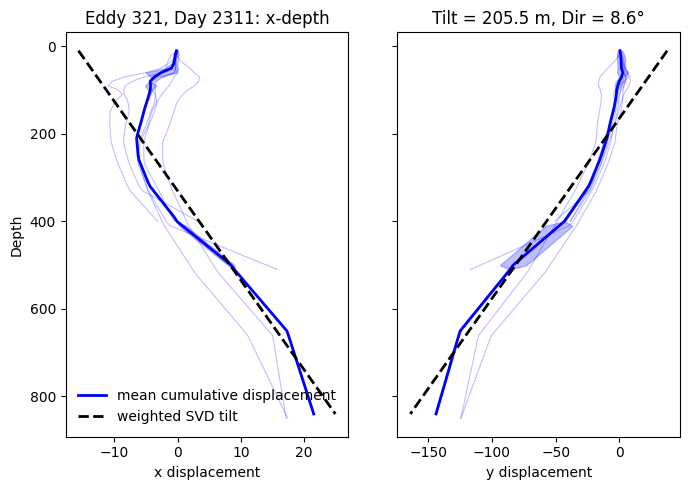

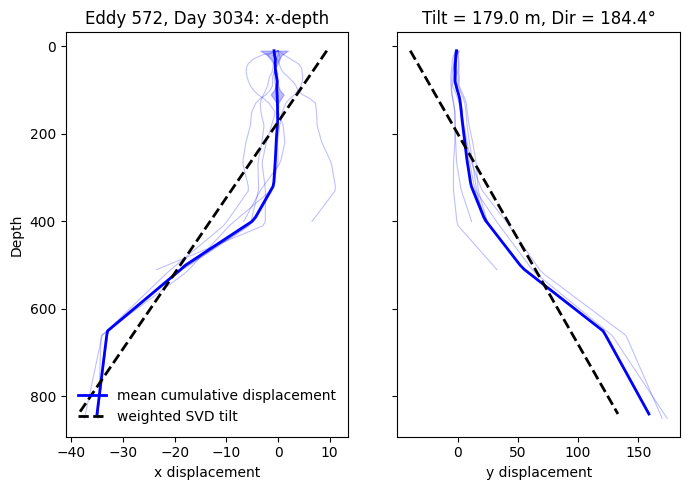

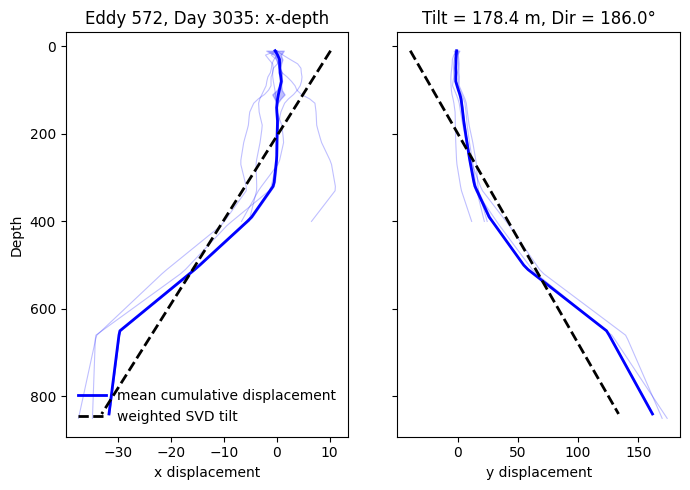

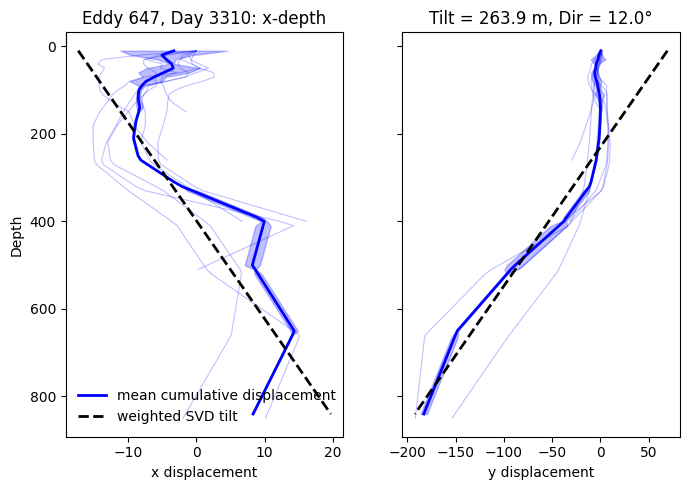

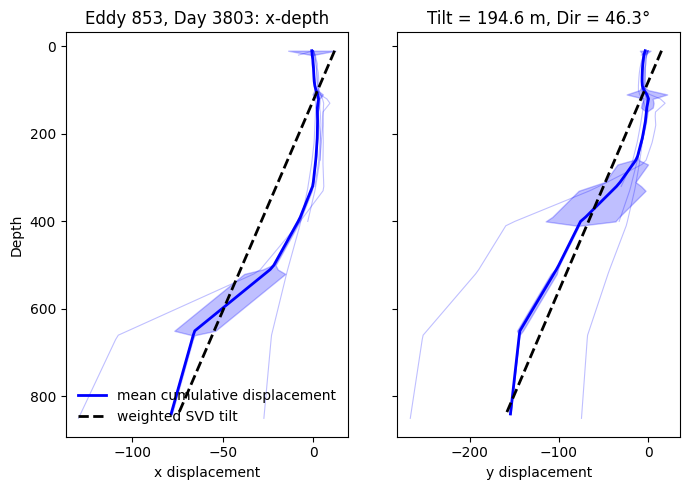

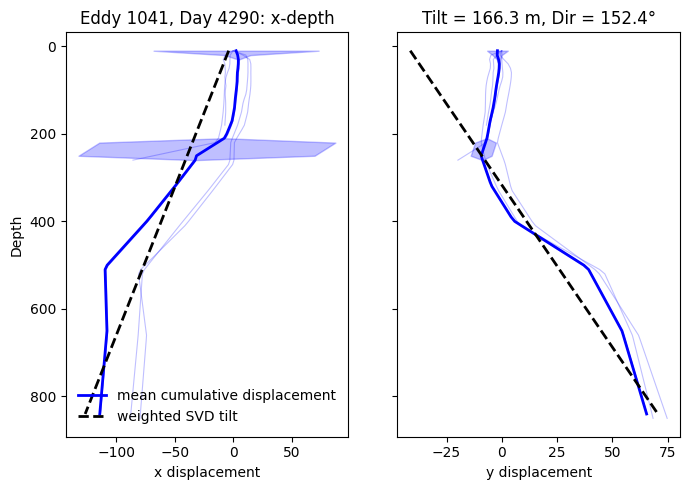

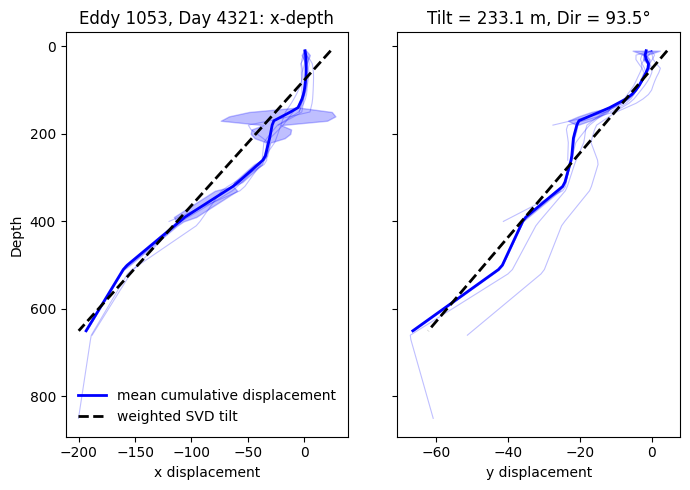

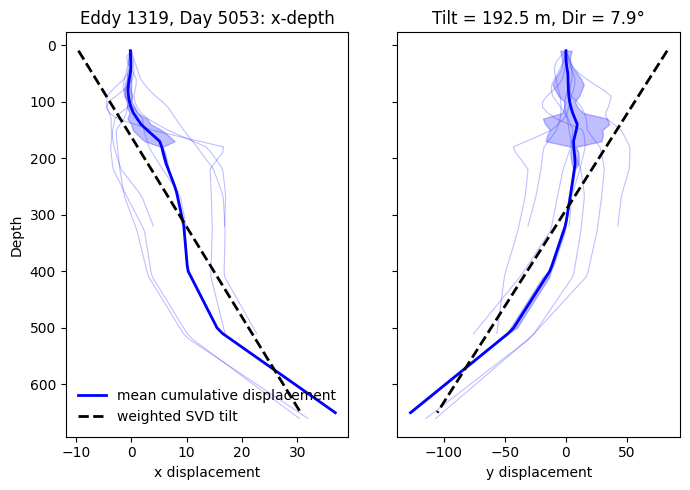

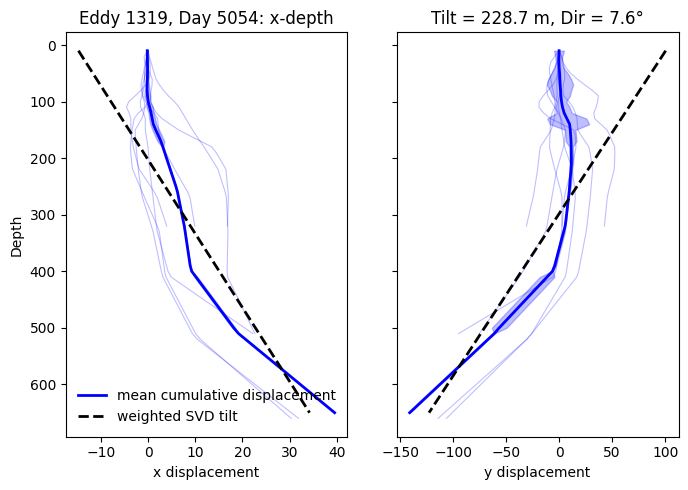

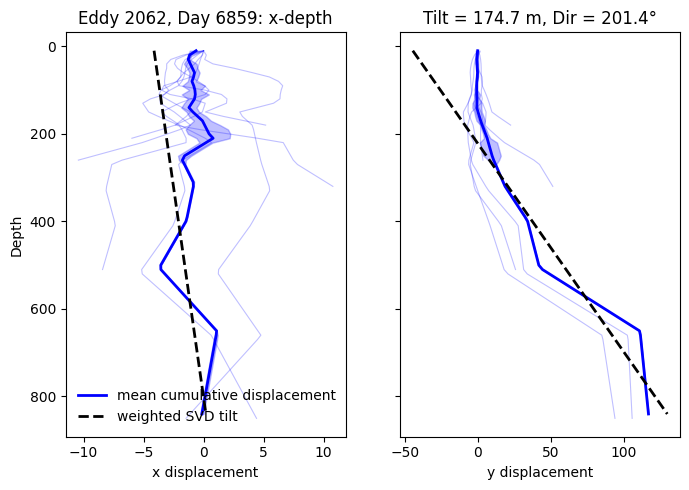

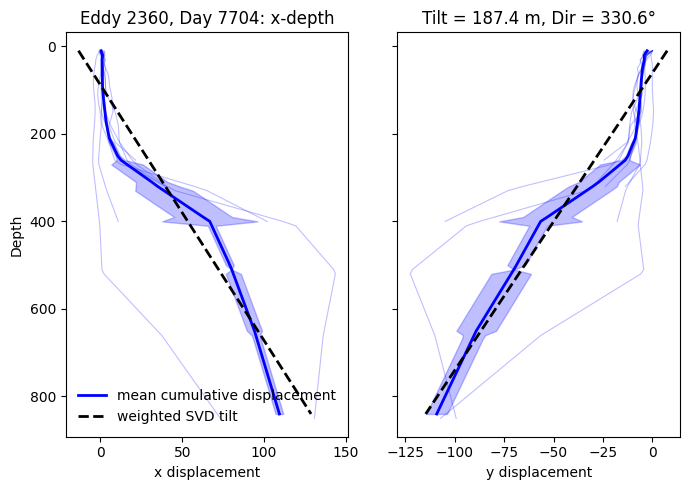

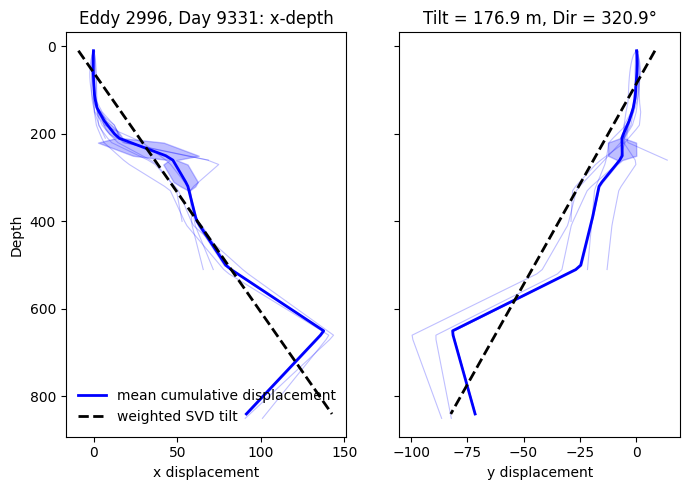

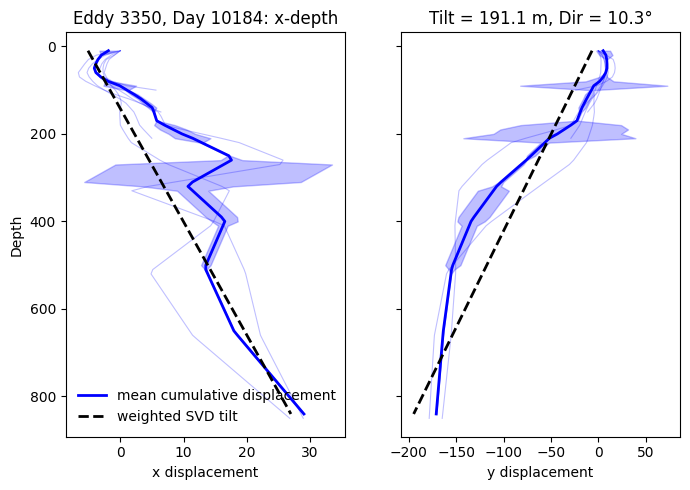

In [24]:
for k in range(len(df_over_tilt)):

    data = df_over_tilt.iloc[k]
    eddy, ref_day = data.Eddy, data.day_idx
    
    plot_tilt_method(
        dic_all=dic_vert,
        eddy=eddy,
        ref_day_idx=ref_day,
        ax_x=None,
        ax_y=None,
        num=6,
        depth_int=10,
        max_depth=1000,
        min_depth_range=200,
        color='b',
        show=True
    )
    

In [14]:
df_large_diff = df_ameda[df_ameda.tdiff_abs > 175]
df_large_diff


,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,interaction,interaction2,area,deta,TiltDis,TiltDir,day_idx,max_spread,tdiff,tdiff_abs
2774,77,1646,AE,158.127519,-32.737261,230,191,750.074555,941.261446,0.000011,...,NaN,NaN,5731.510884,-6.042630e-05,16.880982,340.422168,13,198.327179,181.446198,181.446198
2778,77,1650,AE,157.867611,-32.821959,227,187,729.336584,923.907052,0.000015,...,NaN,NaN,3585.977711,-1.268923e-05,10.464774,334.994985,17,203.388487,192.923713,192.923713
5588,175,1883,AE,159.055761,-34.727664,255,154,892.083164,760.007374,0.000020,...,NaN,NaN,5284.342051,-4.035249e-05,20.853159,22.744178,26,212.851860,191.998701,191.998701
12092,395,2562,AE,158.981501,-27.697728,215,304,668.588524,1500.961369,0.000016,...,NaN,NaN,3784.536884,-1.242847e-04,6.976281,33.922522,45,225.064859,218.088578,218.088578
15692,507,2865,AE,157.496314,-39.089613,253,50,879.762694,247.044689,0.000009,...,3384.0,NaN,2465.735613,1.188027e-07,7.052711,303.993054,16,193.636364,186.583653,186.583653
19712,647,3310,AE,154.488809,-32.398469,154,174,413.157910,859.564127,0.000013,...,4401.0,NaN,7331.768264,-7.917809e-05,263.926561,11.968629,32,57.515402,206.411159,206.411159
22422,730,3501,AE,155.008624,-27.528332,111,280,290.929722,1384.603758,0.000021,...,NaN,NaN,3106.476389,-2.377688e-04,4.913034,286.762272,11,189.139645,184.226611,184.226611
22492,734,3507,AE,158.907242,-29.645783,226,262,724.520202,1293.284763,0.000011,...,NaN,NaN,1306.071802,-1.809721e-05,41.254741,112.106734,15,231.646972,190.392231,190.392231
26083,853,3803,AE,157.830481,-31.720885,219,210,691.596491,1038.916078,0.000014,...,NaN,NaN,5722.899306,-3.422622e-05,194.626280,46.313847,16,16.476962,178.149318,178.149318
26084,853,3804,AE,157.719092,-31.763234,218,209,682.838393,1030.815730,0.000020,...,NaN,NaN,1247.399896,-5.262311e-05,71.244853,18.748572,17,321.094661,249.849809,249.849809


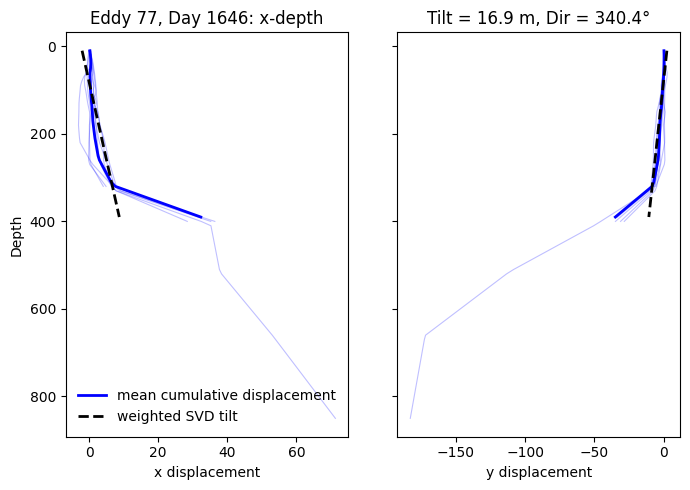

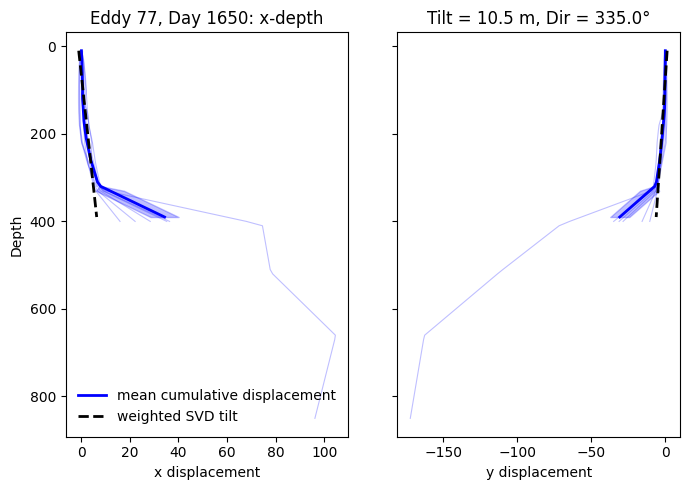

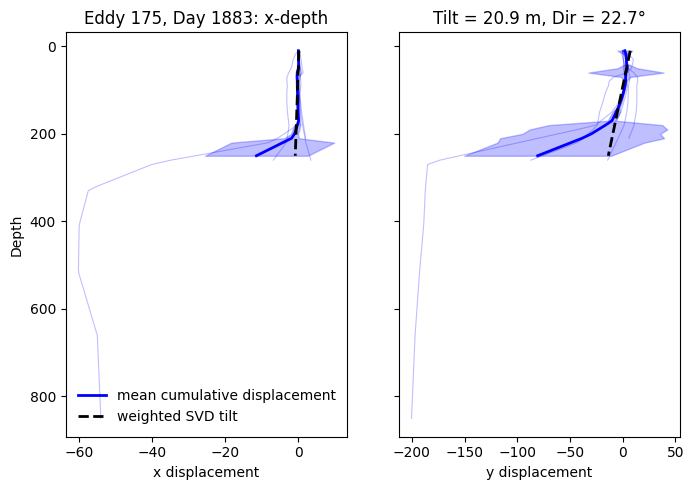

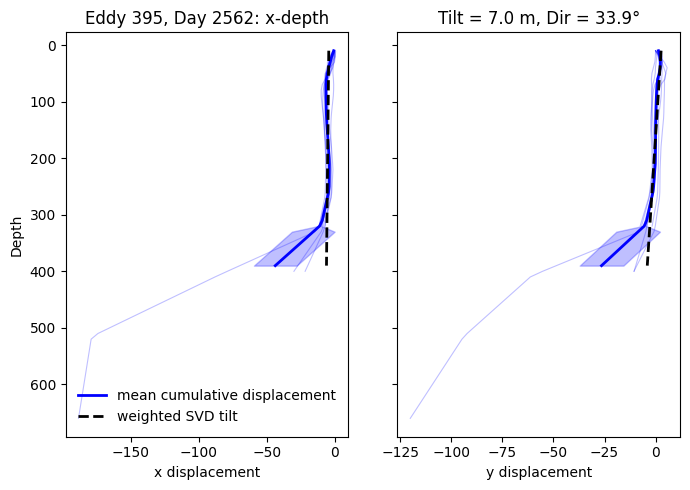

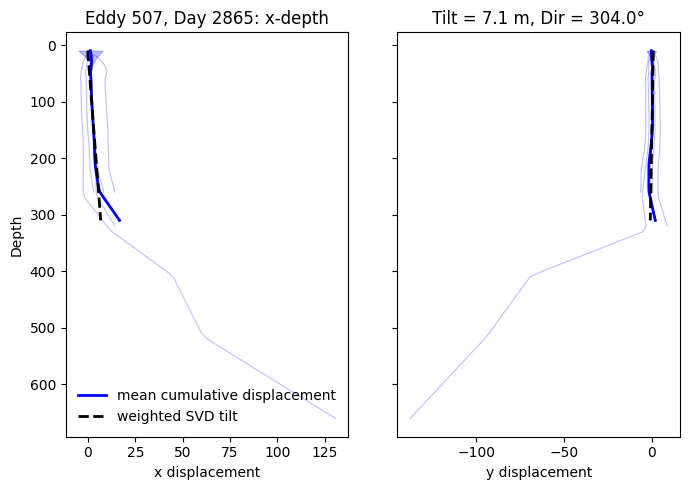

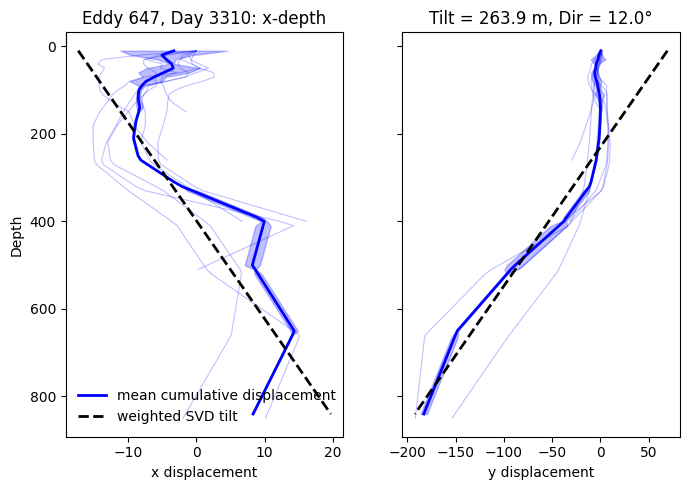

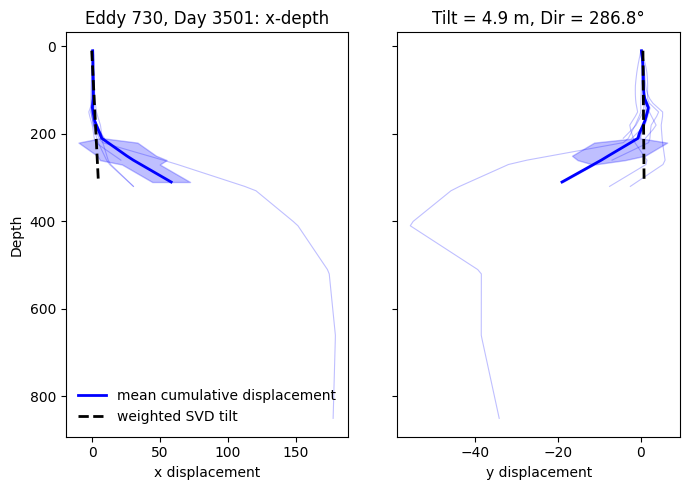

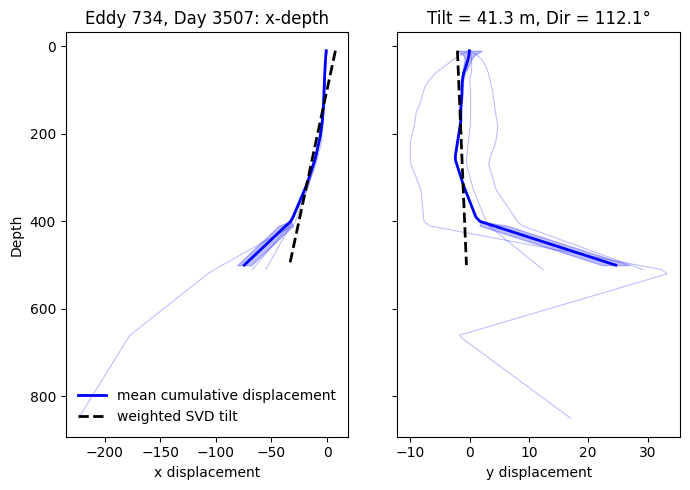

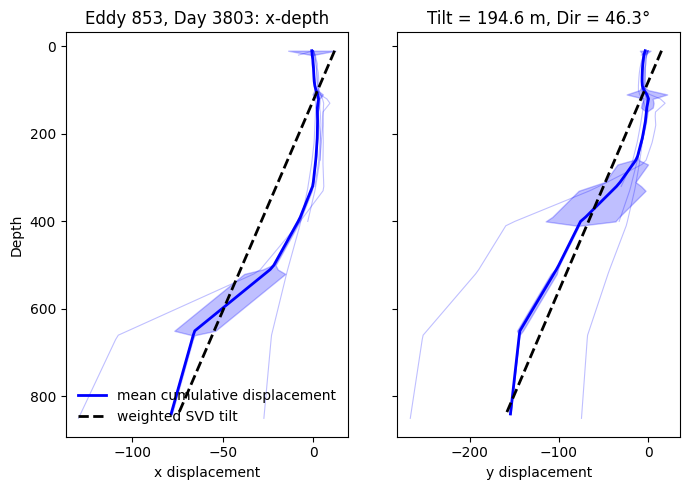

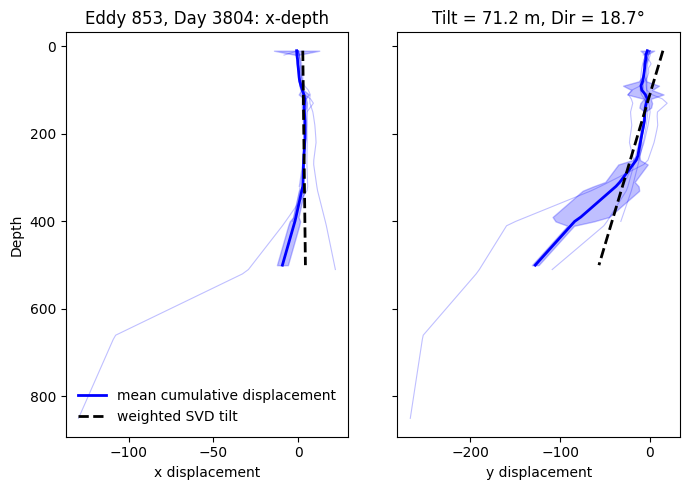

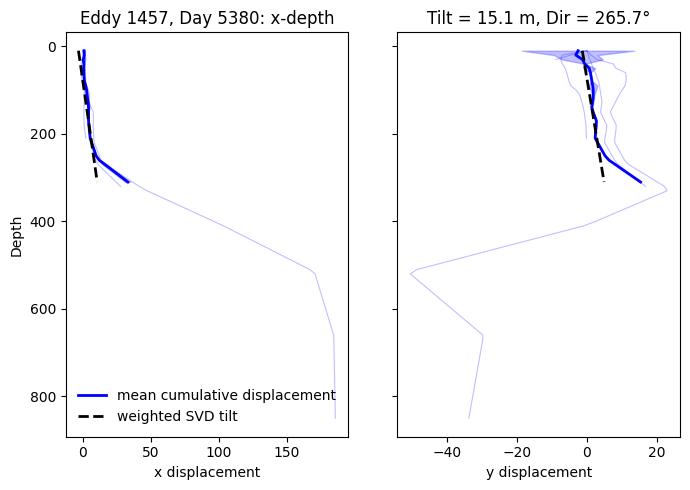

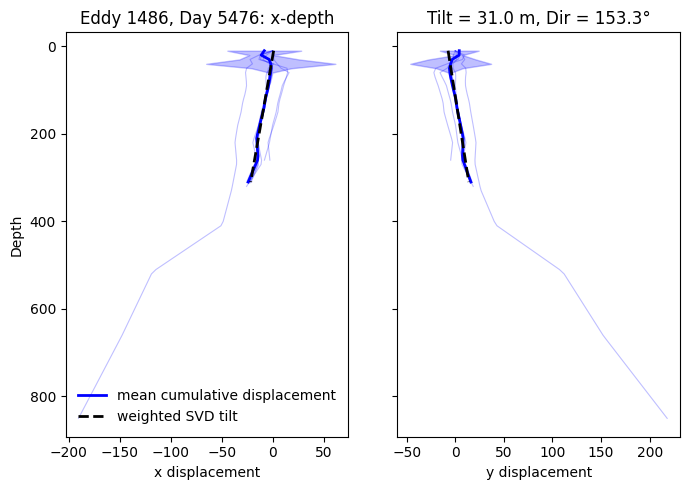

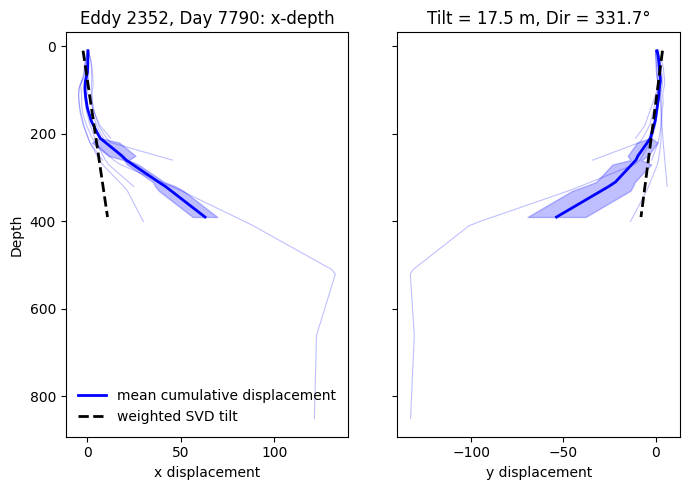

In [15]:
for k in range(len(df_large_diff)):

    data = df_large_diff.iloc[k]
    eddy, ref_day = data.Eddy, data.day_idx
    
    plot_tilt_method(
        dic_all=dic_vert,
        eddy=eddy,
        ref_day_idx=ref_day,
        ax_x=None,
        ax_y=None,
        num=6,
        depth_int=10,
        max_depth=1000,
        min_depth_range=200,
        color='b',
        show=True
    )
    

In [11]:
plot_tilt_method(
    dic_all=dic_vert,
    eddy=627,
    ref_day_idx=50,
    ax_x=None,
    ax_y=None,
    num=6,
    depth_int=10,
    max_depth=1000,
    min_depth_range=200,
    color='b',
    show=True
)


Eddy 627: ref_day_idx outside valid compute_tilt_data range.


(None,
 None,
 Empty DataFrame
 Columns: []
 Index: [])